In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import missingno as mnsno
import seaborn as sns
from collections import Counter

In [3]:
dff = pd.read_csv(r"C:\Users\USER\Desktop\Desktop folder\dune_sales2.csv")

In [6]:
dff.columns

Index(['Date', 'Customer', 'Sales Person', 'Customer_Age', 'Customer_Gender',
       'State', 'Product_Category', 'Sub_Category', 'Payment Option',
       'Quantity', 'Unit_Cost', 'Unit_Price', 'year', 'month', 'month_name',
       'quarter', 'Cost', 'Revenue', 'Profit', 'profit_label', 'Age_group'],
      dtype='object')

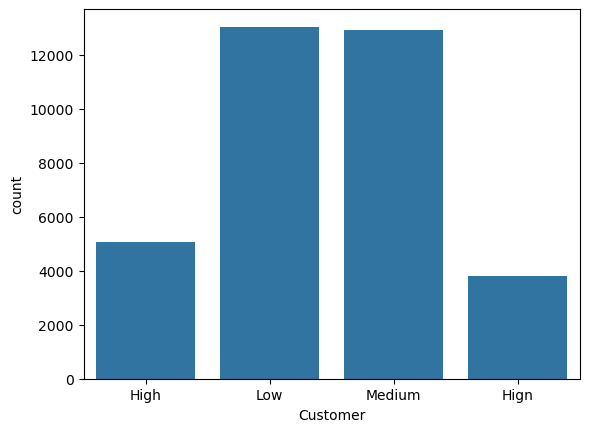

In [9]:
sns.countplot(x='Customer',data=dff);

In [17]:
dff.loc[dff["Customer"]=="Hign","Customer"] ="High"

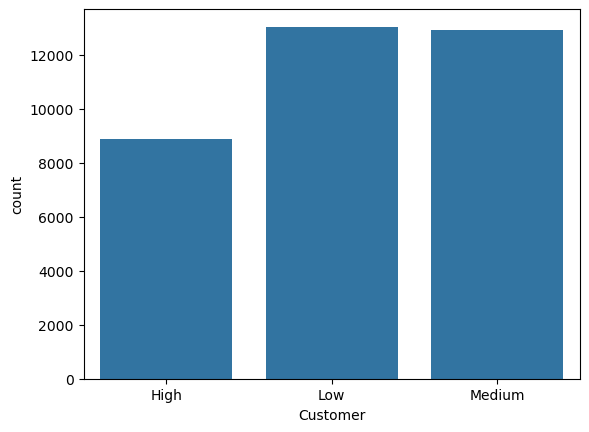

In [19]:
sns.countplot(x="Customer",data=dff);

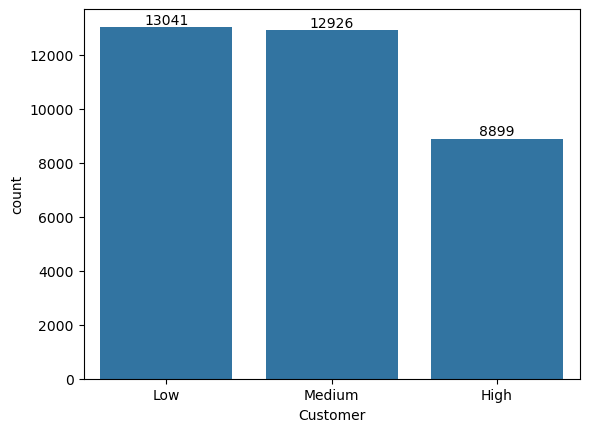

In [22]:
ax = sns.countplot(x=dff["Customer"],order=dff["Customer"].value_counts(ascending=False).index)
values = dff["Customer"].value_counts(ascending=False).values
ax.bar_label(container=ax.containers[0],labels=values);

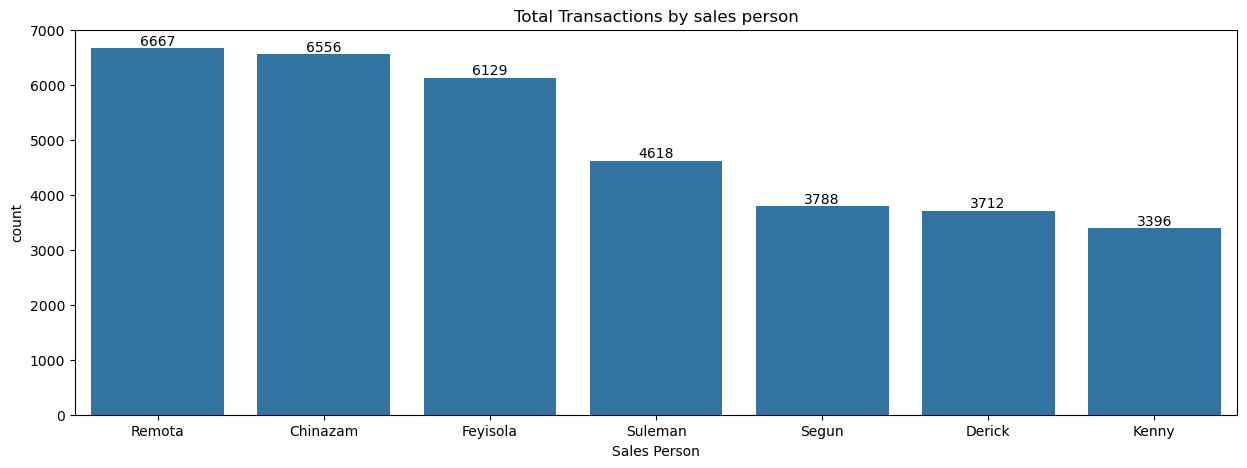

In [26]:
plt.figure(figsize=(15,5))
ax = sns.countplot(x=dff["Sales Person"],order=dff["Sales Person"].value_counts(ascending=False).index)
ax.bar_label(container=ax.containers[0])
plt.title("Total Transactions by sales person");

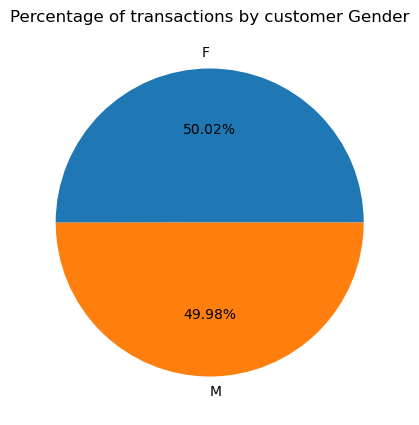

In [28]:
fig,ax = plt.subplots(figsize=(5,5))
count=Counter(dff["Customer_Gender"])
ax.pie(count.values(),labels=count.keys(),autopct=lambda p:f'{p:.2f}%')
ax.set_title("Percentage of transactions by customer Gender")
plt.show();

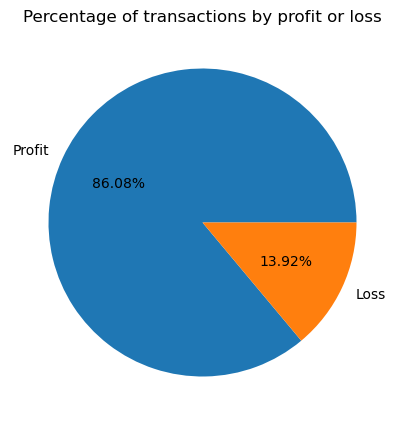

In [29]:
# Total Transactions by profit or loss

fig,ax = plt.subplots(figsize=(5,5))
count=Counter(dff["profit_label"])
ax.pie(count.values(),labels=count.keys(),autopct=lambda p:f'{p:.2f}%')
ax.set_title("Percentage of transactions by profit or loss")
plt.show();

In [32]:
dff.head(2)

,Date,Customer,Sales Person,Customer_Age,Customer_Gender,State,Product_Category,Sub_Category,Payment Option,Quantity,...,Unit_Price,year,month,month_name,quarter,Cost,Revenue,Profit,profit_label,Age_group
0,2/19/2016,High,Segun,29,F,Abia,Accessories,Keyboard,Online,1,...,109.0,2016,2,February,1,80.0,109.0,29.0,Profit,25-40 Adult
1,2/20/2016,High,Segun,29,F,Abia,Clothing,Polo shirts,Online,2,...,28.5,2016,2,February,1,49.0,57.0,8.0,Profit,25-40 Adult


In [33]:
dff.columns

Index(['Date', 'Customer', 'Sales Person', 'Customer_Age', 'Customer_Gender',
       'State', 'Product_Category', 'Sub_Category', 'Payment Option',
       'Quantity', 'Unit_Cost', 'Unit_Price', 'year', 'month', 'month_name',
       'quarter', 'Cost', 'Revenue', 'Profit', 'profit_label', 'Age_group'],
      dtype='object')

### Bivariate Analysis

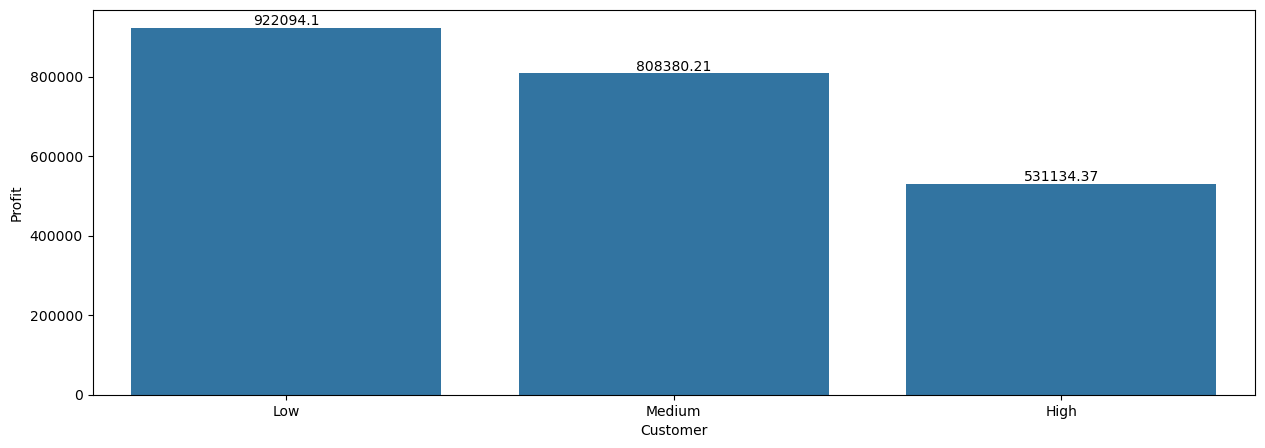

In [39]:
# Profit by Customer

plt.figure(figsize=(15,5))
cust_profit = dff.groupby("Customer")["Profit"].sum().reset_index()
cust_prof_sorted = cust_profit.sort_values(by='Profit',ascending=False)
ax =sns.barplot(x='Customer',y='Profit',data=cust_prof_sorted)
values = cust_prof_sorted['Profit']
ax.bar_label(ax.containers[0],labels=values);

In [40]:
dff.columns

Index(['Date', 'Customer', 'Sales Person', 'Customer_Age', 'Customer_Gender',
       'State', 'Product_Category', 'Sub_Category', 'Payment Option',
       'Quantity', 'Unit_Cost', 'Unit_Price', 'year', 'month', 'month_name',
       'quarter', 'Cost', 'Revenue', 'Profit', 'profit_label', 'Age_group'],
      dtype='object')

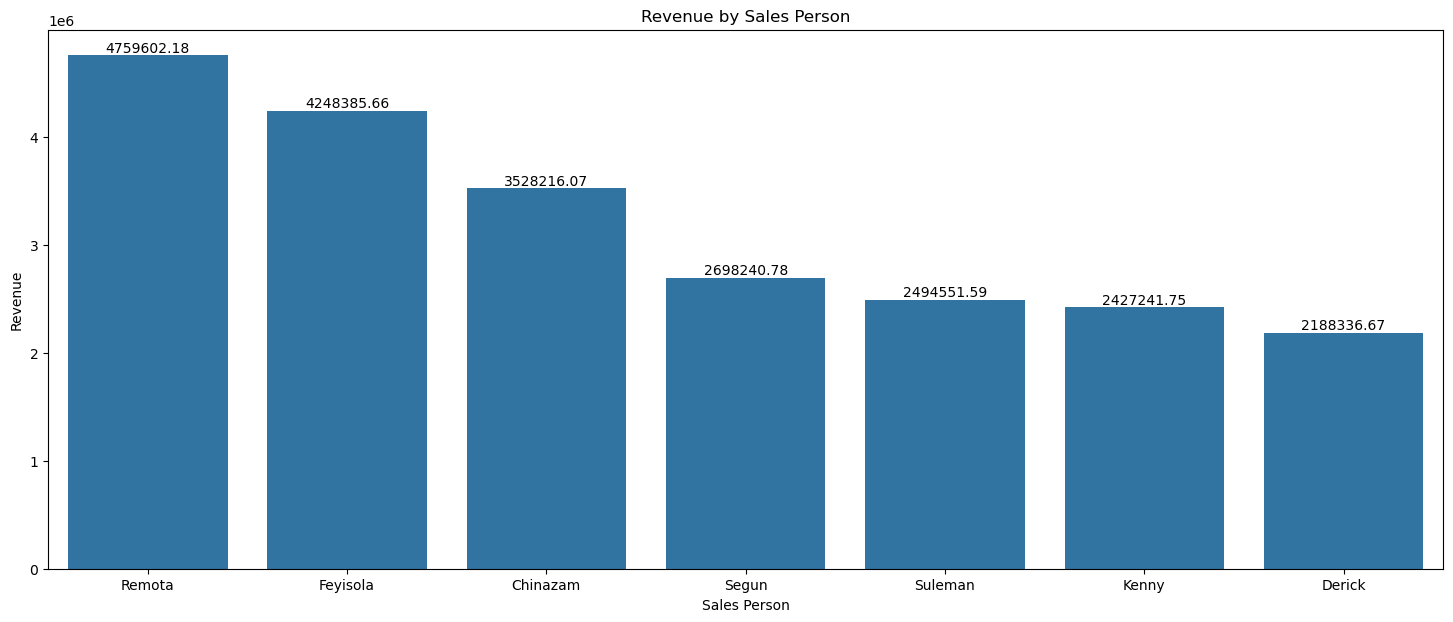

In [67]:
# Total Revenue by sales person

plt.figure(figsize=(18,7))
sp_rev =dff.groupby("Sales Person")["Revenue"].sum().reset_index()
sp_rev_sorted = sp_rev.sort_values(by="Revenue",ascending=False)
ax = sns.barplot(x='Sales Person',data=sp_rev_sorted,y='Revenue')
values = sp_rev_sorted['Revenue']
ax.bar_label(container=ax.containers[0],labels=values)
plt.title("Revenue by Sales Person");
                                   

In [48]:
dff.columns

Index(['Date', 'Customer', 'Sales Person', 'Customer_Age', 'Customer_Gender',
       'State', 'Product_Category', 'Sub_Category', 'Payment Option',
       'Quantity', 'Unit_Cost', 'Unit_Price', 'year', 'month', 'month_name',
       'quarter', 'Cost', 'Revenue', 'Profit', 'profit_label', 'Age_group'],
      dtype='object')

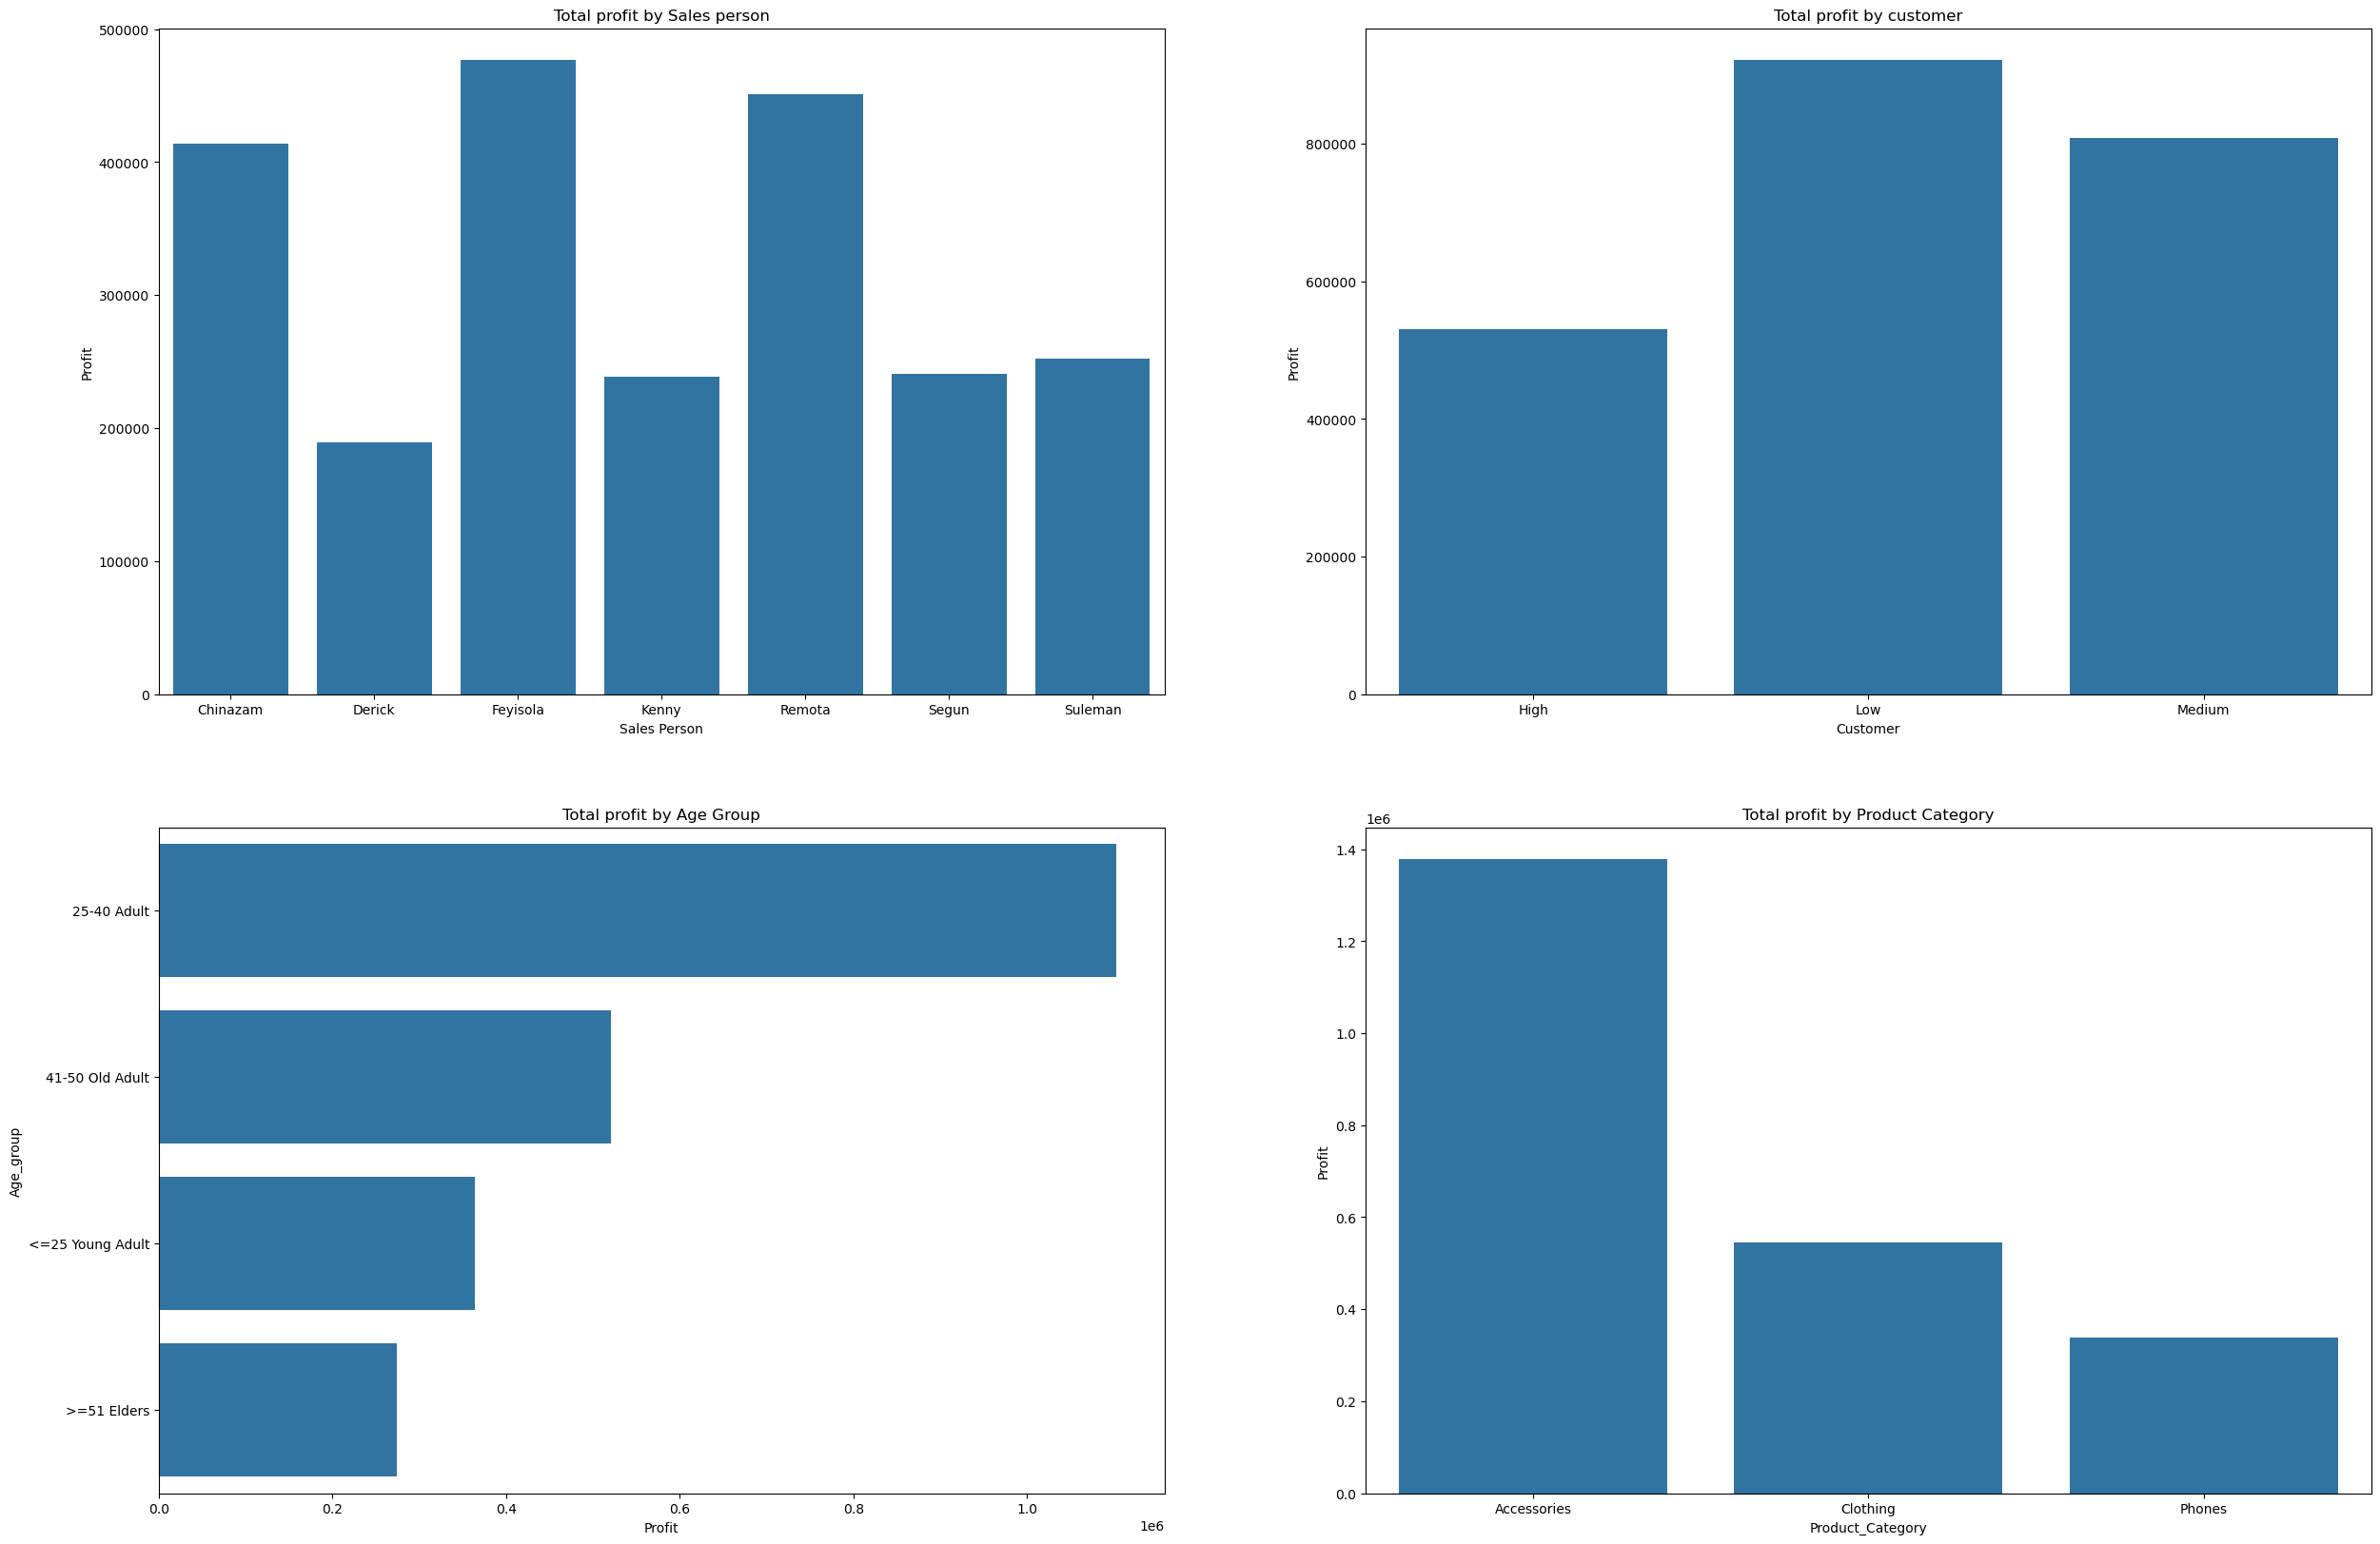

In [62]:
fig,axs =plt.subplots(nrows=2,ncols=2,figsize=(30,20))

SP_prof= dff.groupby("Sales Person")["Profit"].sum().reset_index()
sns.barplot(x='Sales Person',data=SP_prof,y='Profit',ax=axs[0,0])
axs[0,0].set_title("Total profit by Sales person")

cust_prof= dff.groupby("Customer")["Profit"].sum().reset_index()
sns.barplot(x='Customer',data=cust_prof,y='Profit',ax=axs[0,1])
axs[0,1].set_title("Total profit by customer")

Ag_prof= dff.groupby("Age_group")["Profit"].sum().reset_index()
sns.barplot(y='Age_group',data=Ag_prof,x='Profit',ax=axs[1,0])
axs[1,0].set_title("Total profit by Age Group")

pc_prof= dff.groupby("Product_Category")["Profit"].sum().reset_index()
sns.barplot(x='Product_Category',data=pc_prof,y='Profit',ax=axs[1,1])
axs[1,1].set_title("Total profit by Product Category");
    
    

In [68]:
dff.columns

Index(['Date', 'Customer', 'Sales Person', 'Customer_Age', 'Customer_Gender',
       'State', 'Product_Category', 'Sub_Category', 'Payment Option',
       'Quantity', 'Unit_Cost', 'Unit_Price', 'year', 'month', 'month_name',
       'quarter', 'Cost', 'Revenue', 'Profit', 'profit_label', 'Age_group'],
      dtype='object')

### Multivariate Analysis


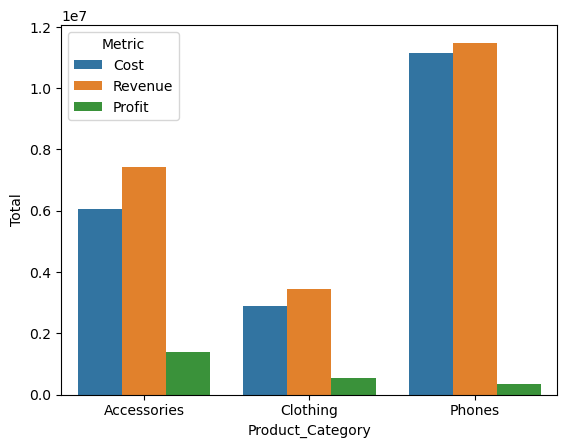

In [72]:
# Product category against cost,Revenue and profit
procat = dff.groupby("Product_Category")[["Cost","Revenue","Profit"]].sum().reset_index()
procat = pd.melt(procat, id_vars="Product_Category",var_name="Metric",value_name="Total")
sns.barplot(data=procat,x='Product_Category',y="Total",hue="Metric");

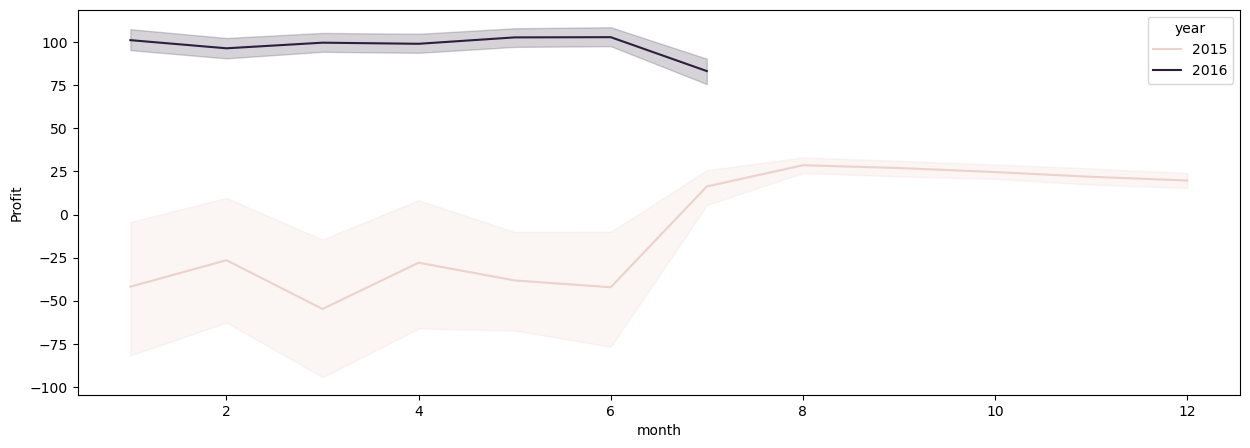

In [127]:
plt.figure(figsize=(15,5))
sns.lineplot(x='month',y='Profit',data=dff,hue='year');

In [84]:
# using pivot table
dff.pivot_table(values='Profit',index='year',columns='month',aggfunc='sum')

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2015,-5778.70,-4079.65,-8163.79,-4945.69,-7801.45,-8690.61,15104.47,65926.24,62172.33,62950.66,54480.9,67448.12
2016,280204.25,263640.18,299777.67,307746.51,356915.59,357549.86,107151.79,NaN,NaN,NaN,NaN,NaN


In [101]:
dff.columns

Index(['Date', 'Customer', 'Sales Person', 'Customer_Age', 'Customer_Gender',
       'State', 'Product_Category', 'Sub_Category', 'Payment Option',
       'Quantity', 'Unit_Cost', 'Unit_Price', 'year', 'month', 'month_name',
       'quarter', 'Cost', 'Revenue', 'Profit', 'profit_label', 'Age_group'],
      dtype='object')

In [103]:
customer =dff["Customer"].value_counts()
customer

Customer
Low       13041
Medium    12926
High       8899
Name: count, dtype: int64

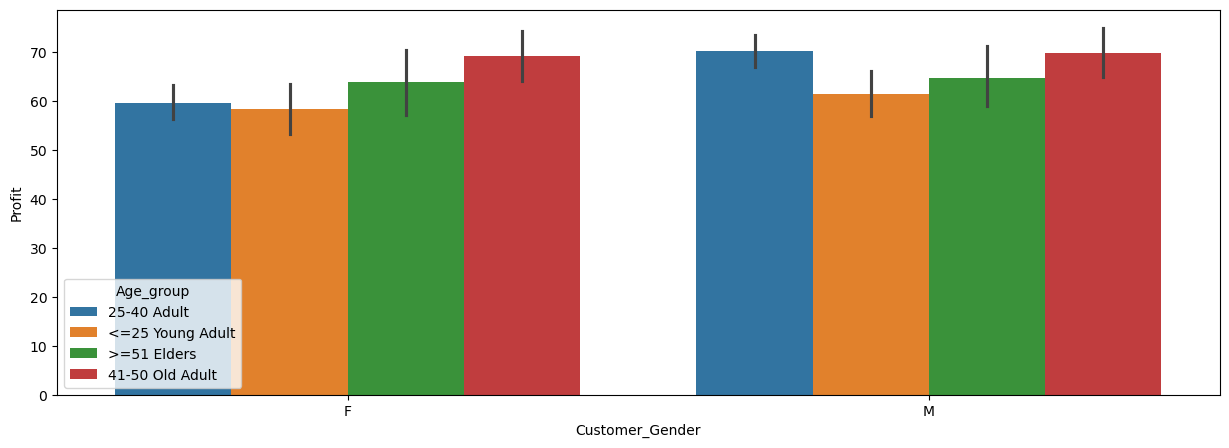

In [106]:
# customer Gender,Age group and profit
plt.figure(figsize=(15,5))
sns.barplot(x="Customer_Gender",y="Profit",data=dff,hue="Age_group");

In [115]:
from datetime import datetime

In [118]:
dff["Date"]=pd.to_datetime(dff["Date"])

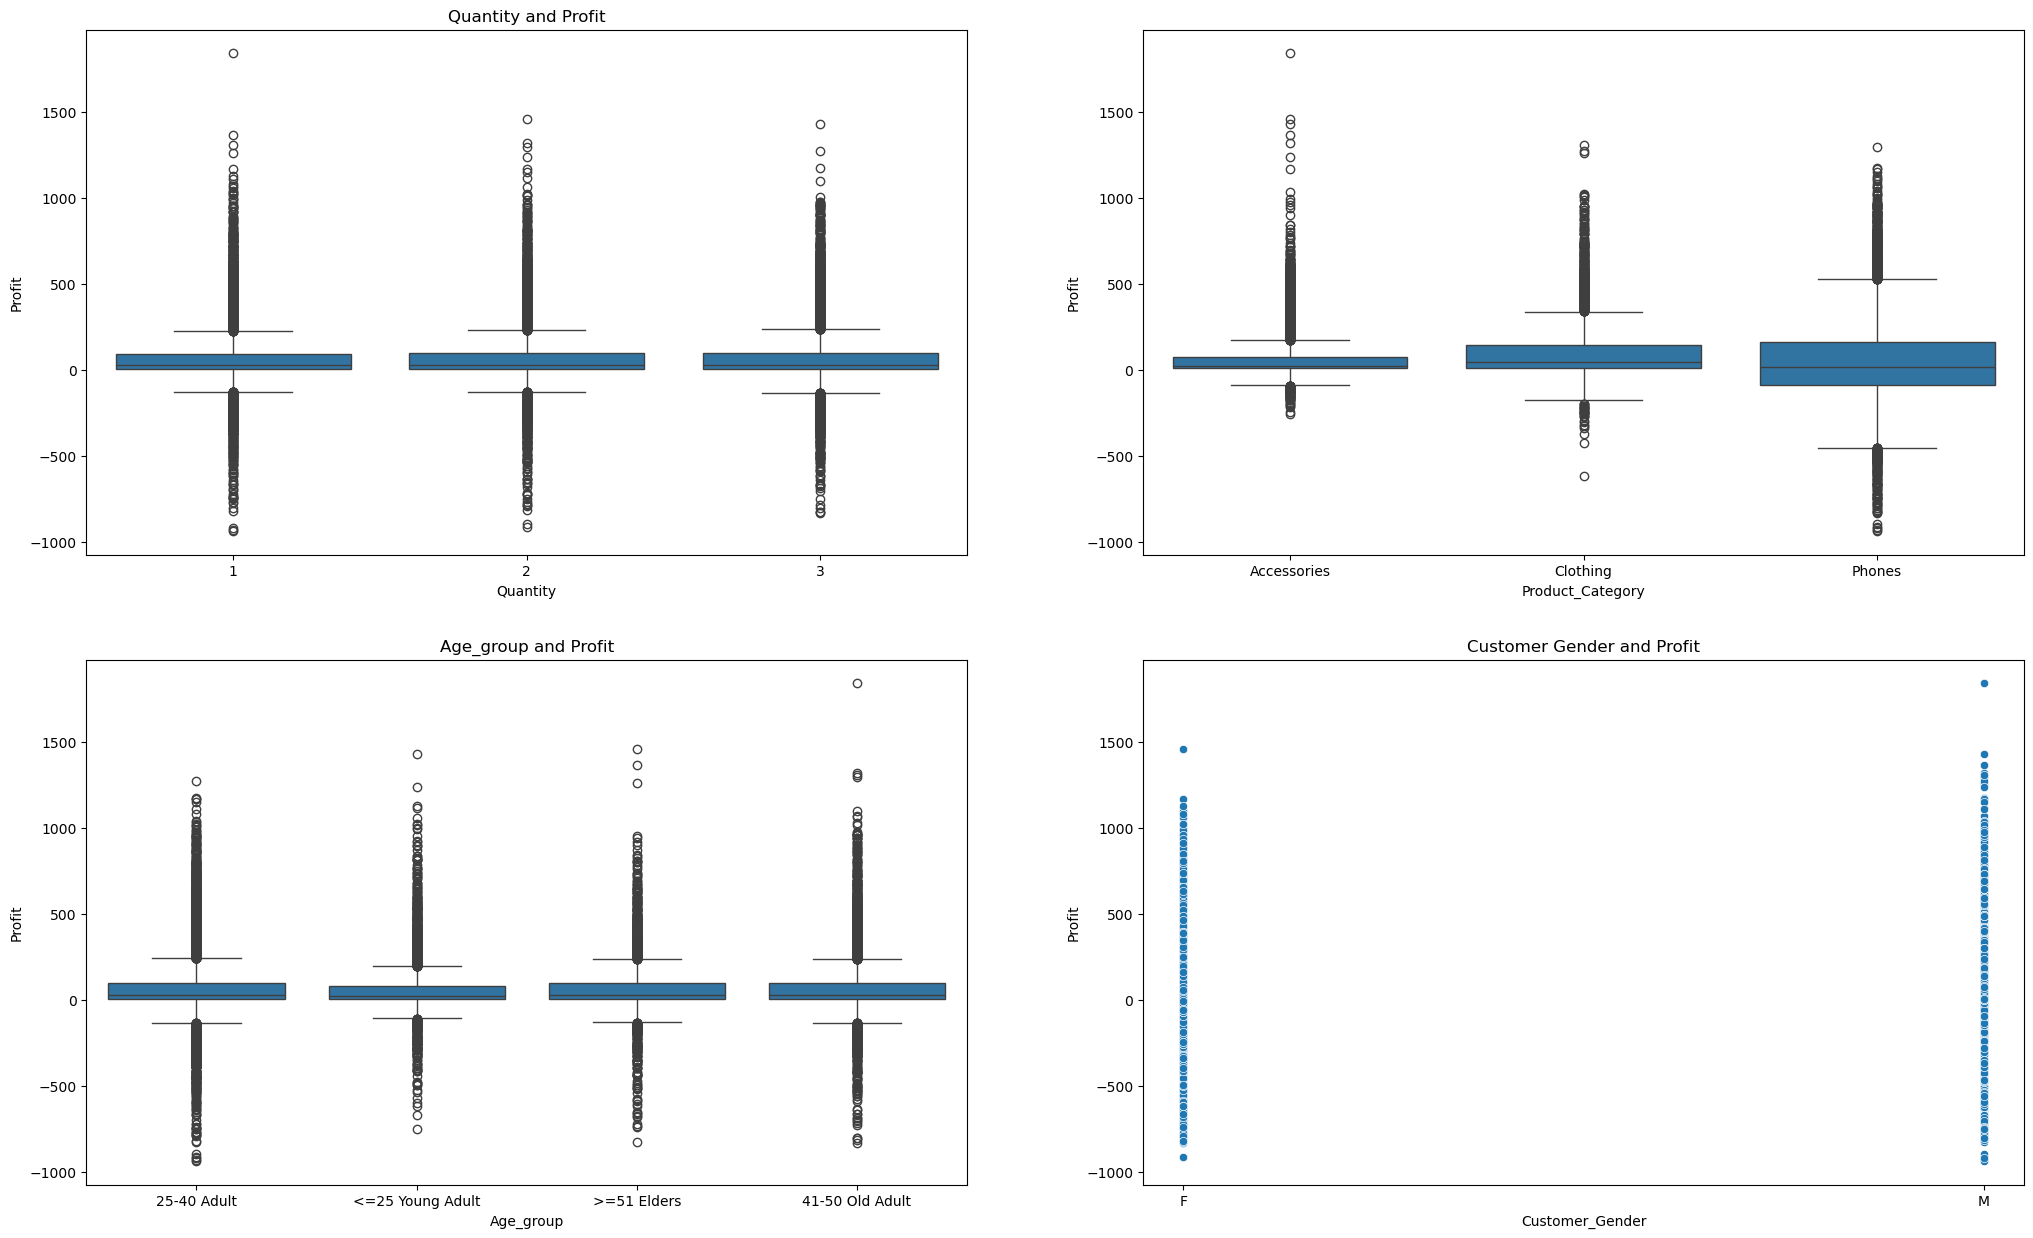

In [125]:
fig,axs=plt.subplots(nrows=2,ncols=2,figsize=(25,15))
sns.boxplot(x='Quantity',y='Profit',data=dff,ax=axs[0,0])
axs[0,0].set_title("Quantity and Profit")

sns.boxplot(x='Product_Category',y='Profit',data=dff,ax=axs[0,1])
axs[1,0].set_title("Product Category and Profit")

sns.boxplot(x='Age_group',y='Profit',data=dff,ax=axs[1,0])
axs[1,0].set_title("Age_group and Profit")

sns.scatterplot(x='Customer_Gender',y='Profit',data=dff,ax=axs[1,1])
axs[1,1].set_title("Customer Gender and Profit");



In [126]:
dff.to_csv('Desktop/dunes_sales3.csv',index=False)